# 03a — Step 1 reproduction: a country's natural-regeneration area from the published map

**Question.** Do the country numbers in Williams et al. (2024) follow from the
authors' own published 30 m map (Zenodo
[10.5281/zenodo.7428804](https://doi.org/10.5281/zenodo.7428804))?

The country is a parameter: environment variable `ISO3` (default `COL`).
Colombia is the replication's study country; Costa Rica (`ISO3=CRI`) is run as
a second-country check of the area-method finding. Paper values are read
directly from Supp. Tables 3 and 4 (`paper/supplementary/`, MOESM5 / MOESM6).

| Paper value (Colombia, Neotropics; default run) | Mha | Source |
|---|---|---|
| Potential for natural regeneration, continuous (expected) area | 11.19 | Supp. Table 3 |
| Potential for natural regeneration, binary > 50 % | 13.70 | Supp. Table 4 |
| Area available for restoration | 93.78 | Supp. Tables 3 and 4 |

**Method.**

- Country mask: GADM 4.1 level 0 polygon (paper: "GADM (2022)"). A 30 m pixel
  belongs to Colombia when its **centre** lies inside the polygon (GDAL rasterize
  default rule).
- Pixel area: the raster is on a regular 0.00025° lon/lat grid (EPSG:4326), so
  a pixel's area depends only on its row. We compute it three ways:
  1. **`ellipsoid_wgs84`**: the exact area of the lon/lat cell on the WGS84
     ellipsoid (closed form with the authalic `q` function, checked against
     `pyproj.Geod` below). This is the reference.
  2. **`sphere_a_mollweide`**: the area the paper's stated method gives. The
     paper computes areas "in Mollweide projection". PROJ's Mollweide (`ESRI:54009`,
     `+proj=moll +datum=WGS84`) is a spherical projection that uses the semi-major
     axis *a* as the sphere radius, so an equal-area Mollweide area equals the
     area on a sphere of radius *a* = 6,378,137 m (verified numerically below).
  3. **`nominal_900m2`**: every pixel counted as 30 m × 30 m = 900 m² (0.09 ha,
     the per-cell area the paper uses for carbon), applied to the native
     0.00025° lon/lat pixels without reprojection. At Colombia's latitudes a
     0.00025° pixel is ~740–770 m², so this overstates area by ~17–21 %.
- Continuous product: values are integer percentages (0–100, 255 = NoData).
  Expected area = Σ area × pct / 100. Because of integer storage, the true
  expected area lies within Σ area × (pct ± 0.5) / 100 if values were rounded,
  or within [pct, pct + 1) if truncated; both bounds are reported. The product
  has almost no 0 values: pixels whose probability rounds (or truncates) to 0 %
  appear to be stored as NoData. Their missing mass is bounded by treating
  pixels that are NoData in the continuous product but 0 in the binary product
  as p ∈ [0, 0.5 %) (rounding) or [0, 1 %) (truncation).
- Binary product (`pnv_bin_30m`, 0/1, 3 = NoData): area = Σ area where value = 1.
  It is compared with the continuous product thresholded at > 50 % and ≥ 50 %.
- "Available for restoration": the paper does not define the mask. We report
  candidate definitions (valid pixels of each product) and compare them with 93.78 Mha.
- HEALPix aggregation (for the step-2 map comparison): each 30 m pixel centre
  is assigned to its HEALPix depth-8 NESTED cell on the WGS84 ellipsoid
  (`healpix_geo.nested.lonlat_to_healpix(..., ellipsoid="WGS84")`), and exact
  ellipsoidal pixel areas are summed per cell. No resampling.

This step reuses the **authors' outputs**, not their code (available on request
only).

In [1]:
import json
import multiprocessing as mp
import os
from dataclasses import dataclass
from pathlib import Path

import docx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
import shapely
import xarray as xr
from healpix_geo.nested import healpix_to_lonlat, lonlat_to_healpix
from pyproj import Geod, Transformer
from rasterio.features import rasterize
from rasterio.windows import Window

In [2]:
RAW_DIR = Path("../data/raw")
ZEN_DIR = RAW_DIR / "zenodo_7428804"
RESULTS_DIR = Path("../results")
FIGURES_DIR = Path("../figures")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RES = 0.00025  # native pixel size, degrees
BLOCK_ROWS = 256
HEALPIX_DEPTH = 8  # ~25 km cells
N_WORKERS = int(os.environ.get("N_WORKERS", min(14, os.cpu_count() or 1)))
PCT_NODATA, BIN_NODATA = 255, 3

ISO3 = os.environ.get("ISO3", "COL").upper()
TAG = "colombia" if ISO3 == "COL" else ISO3.lower()  # keeps the original Colombia file names
SUPP_DIR = Path("../paper/supplementary")

## Pixel-area models

In [3]:
WGS84_A = 6378137.0
WGS84_F = 1 / 298.257223563
E2 = WGS84_F * (2 - WGS84_F)
E = np.sqrt(E2)


def _q(phi: np.ndarray) -> np.ndarray:
    s = np.sin(phi)
    return (1 - E2) * (s / (1 - E2 * s * s) - np.log((1 - E * s) / (1 + E * s)) / (2 * E))


def cell_area_ellipsoid(lat_top: np.ndarray, dlon: float = RES, dlat: float = RES) -> np.ndarray:
    """Exact WGS84 area (m²) of lon/lat cells between lat_top - dlat and lat_top."""
    top, bot = np.radians(lat_top), np.radians(lat_top - dlat)
    return WGS84_A**2 / 2 * np.radians(dlon) * (_q(top) - _q(bot))


def cell_area_sphere_a(lat_top: np.ndarray, dlon: float = RES, dlat: float = RES) -> np.ndarray:
    """Area (m²) on a sphere of radius a = what PROJ's WGS84 Mollweide preserves."""
    top, bot = np.radians(lat_top), np.radians(lat_top - dlat)
    return WGS84_A**2 * np.radians(dlon) * (np.sin(top) - np.sin(bot))

Check both formulas: ellipsoid against `pyproj.Geod` (geodesic polygon area),
sphere-*a* against the planar area of the cell projected to `ESRI:54009` Mollweide.

In [4]:
geod = Geod(ellps="WGS84")
to_moll = Transformer.from_crs("EPSG:4326", "ESRI:54009", always_xy=True)
checks = []
for lat in [-4.0, 0.0, 4.0, 8.0, 12.0, 15.9]:
    xs = [-74.0, -74.0 + RES, -74.0 + RES, -74.0]
    ys = [lat, lat, lat + RES, lat + RES]
    g_area = abs(geod.polygon_area_perimeter(xs, ys)[0])
    mx, my = to_moll.transform(xs, ys)
    m_area = 0.5 * abs(sum(mx[i] * my[(i + 1) % 4] - mx[(i + 1) % 4] * my[i] for i in range(4)))
    e_area = float(cell_area_ellipsoid(np.array([lat + RES]))[0])
    s_area = float(cell_area_sphere_a(np.array([lat + RES]))[0])
    checks.append(
        dict(lat=lat, ellipsoid=e_area, geod=g_area, sphere_a=s_area, mollweide_planar=m_area,
             sphere_over_ellipsoid=s_area / e_area - 1)
    )
checks = pd.DataFrame(checks)
print(checks.to_string(float_format=lambda v: f"{v:.6g}"))
assert np.allclose(checks.ellipsoid, checks.geod, rtol=1e-8)
assert np.allclose(checks.sphere_a, checks.mollweide_planar, rtol=1e-5)

   lat  ellipsoid    geod  sphere_a  mollweide_planar  sphere_over_ellipsoid
0   -4    767.493 767.493   772.615           772.615             0.00667391
1    0    769.317 769.317   774.502           774.502              0.0067395
2    4    767.493 767.493   772.615           772.615             0.00667391
3    8    762.027 762.027   766.964           766.964             0.00647843
4   12    752.941 752.941   757.577           757.578             0.00615691
5 15.9    740.628 740.628    744.87           744.869             0.00572809


## Country polygon and tile pairs

In [5]:
col = gpd.read_file(RAW_DIR / "gadm" / f"gadm41_{ISO3}.gpkg", layer="ADM_ADM_0")
COUNTRY = col.COUNTRY.iloc[0]
col_geom = shapely.make_valid(col.geometry.iloc[0])
gadm_area_geodesic = abs(geod.geometry_area_perimeter(col_geom)[0])
print(f"GADM 4.1 {COUNTRY} geodesic polygon area: {gadm_area_geodesic / 1e10:.4f} Mha")


def supp_row(docx_name: str, country: str) -> list[str]:
    for table in docx.Document(SUPP_DIR / docx_name).tables:
        for row in table.rows:
            cells = [c.text.strip() for c in row.cells]
            if cells[0] == country:
                return cells
    raise KeyError(country)


t3 = supp_row("41586_2024_8106_MOESM5_ESM.docx", COUNTRY)
t4 = supp_row("41586_2024_8106_MOESM6_ESM.docx", COUNTRY)
PAPER = {"pnr_continuous": float(t3[3]), "pnr_binary": float(t4[3]), "available": float(t3[2])}
PAPER_PROP = {"continuous": float(t3[4]), "binary": float(t4[4])}
print("Supp. Table 3:", t3, "\nSupp. Table 4:", t4)

sources = json.loads((RAW_DIR / "sources.json").read_text())["sources"]
pct_files = [ZEN_DIR / f["key"] for f in sources[0]["files"]]
bin_files = [ZEN_DIR / "pnv_bin_30m" / k for k in sources[1]["extracted_members"]]


@dataclass(frozen=True)
class TilePair:
    pct: str
    bin: str
    left: float
    top: float
    width: int
    height: int


def snap(v: float) -> float:
    return round(v / RES) * RES


bin_by_bounds = {}
for f in bin_files:
    with rasterio.open(f) as r:
        bin_by_bounds[tuple(round(v, 6) for v in r.bounds)] = (str(f), r.width, r.height)

pairs: list[TilePair] = []
for f in pct_files:
    with rasterio.open(f) as r:
        assert abs(r.res[0] - RES) < 1e-12 and abs(r.res[1] - RES) < 1e-12
        key = tuple(round(v, 6) for v in r.bounds)
        bf, bw, bh = bin_by_bounds[key]
        assert (bw, bh) == (r.width, r.height), f"grid mismatch {f.name}"
        pairs.append(TilePair(str(f), bf, snap(r.bounds.left), snap(r.bounds.top), r.width, r.height))
for p in pairs:
    print(Path(p.pct).name, "<->", Path(p.bin).name)

GADM 4.1 Costa Rica geodesic polygon area: 5.1178 Mha
Supp. Table 3: ['Costa Rica', 'Neotropics', '4.97', '1.03', '0.21'] 
Supp. Table 4: ['Costa Rica', 'Neotropics', '4.97', '1.22', '0.24', '']
pnv_pct_30m_tile_-70_-60_-5_5.tif <-> pnv_bin_30m_tile_14.tif
pnv_pct_30m_tile_-70_-60_5_15.tif <-> pnv_bin_30m_tile_10.tif
pnv_pct_30m_tile_-80_-70_-5_5.tif <-> pnv_bin_30m_tile_13.tif
pnv_pct_30m_tile_-80_-70_15_25.tif <-> pnv_bin_30m_tile_5.tif
pnv_pct_30m_tile_-80_-70_5_15.tif <-> pnv_bin_30m_tile_9.tif
pnv_pct_30m_tile_-90_-80_5_15.tif <-> pnv_bin_30m_tile_8.tif


## Block jobs

Each tile is cut into bands of 256 rows; for each band the polygon is clipped
to the band, and only the column span of the clipped polygon is read.

In [6]:
@dataclass(frozen=True)
class Block:
    tile: int
    row0: int
    nrows: int
    col0: int
    ncols: int


def make_blocks(pairs: list[TilePair], geom) -> list[Block]:
    blocks = []
    for t, p in enumerate(pairs):
        tile_geom = shapely.clip_by_rect(geom, p.left, p.top - p.height * RES, p.left + p.width * RES, p.top)
        if tile_geom.is_empty:
            continue
        _, gminy, _, gmaxy = tile_geom.bounds
        r_start = max(0, int((p.top - gmaxy) / RES) - 1)
        r_end = min(p.height, int(np.ceil((p.top - gminy) / RES)) + 1)
        for r0 in range(r_start, r_end, BLOCK_ROWS):
            n = min(BLOCK_ROWS, r_end - r0)
            band = shapely.clip_by_rect(tile_geom, p.left, p.top - (r0 + n) * RES, p.left + p.width * RES, p.top - r0 * RES)
            if band.is_empty:
                continue
            bminx, _, bmaxx, _ = band.bounds
            c0 = max(0, int((bminx - p.left) / RES) - 1)
            c1 = min(p.width, int(np.ceil((bmaxx - p.left) / RES)) + 1)
            blocks.append(Block(t, r0, n, c0, c1 - c0))
    return blocks


blocks = make_blocks(pairs, col_geom)
print(f"{len(blocks)} blocks, {sum(b.nrows * b.ncols for b in blocks) / 1e9:.2f} G pixels read")

52 blocks, 0.08 G pixels read


## Per-block computation

For every in-country pixel the worker records (pct value, bin value) and, per
row, the pixel area. Output per block:

- `counts[row, pct * 4 + bin]`: pixel counts, folded with the three row-area
  models into area histograms over the 256 × 4 (pct, bin) combinations. Every
  area statistic below is derived from these histograms.
- HEALPix depth-8 sums of ellipsoidal area for several masks.

In [7]:
HP_VARS = ["area_country", "area_pct_valid", "expected_pnr", "area_pct_gt50", "area_bin_valid", "area_bin_pnr"]
_GEOM = None


def _init(geom_wkb: bytes) -> None:
    global _GEOM
    _GEOM = shapely.from_wkb(geom_wkb)


def process_block(job: tuple[TilePair, Block]) -> dict:
    p, b = job
    win = Window(b.col0, b.row0, b.ncols, b.nrows)
    x0, y0 = p.left + b.col0 * RES, p.top - b.row0 * RES
    band = shapely.clip_by_rect(_GEOM, x0 - RES, y0 - (b.nrows + 1) * RES, x0 + (b.ncols + 1) * RES, y0 + RES)
    transform = rasterio.transform.from_origin(x0, y0, RES, RES)
    mask = rasterize([(band, 1)], out_shape=(b.nrows, b.ncols), transform=transform, fill=0, dtype="uint8").astype(bool)
    lat_top = y0 - np.arange(b.nrows) * RES
    out = {"lat_top": lat_top, "counts": np.zeros((b.nrows, 1024), np.int64), "hp_cells": np.empty(0, np.uint64),
           "hp_sums": np.zeros((len(HP_VARS), 0))}
    if not mask.any():
        return out
    with rasterio.open(p.pct) as rp, rasterio.open(p.bin) as rb:
        pct = rp.read(1, window=win)
        bn = rb.read(1, window=win)
    rr, cc = np.nonzero(mask)
    pv, bv = pct[rr, cc].astype(np.int64), bn[rr, cc].astype(np.int64)
    idx = rr.astype(np.int64) * 1024 + pv * 4 + bv
    out["counts"] = np.bincount(idx, minlength=b.nrows * 1024).reshape(b.nrows, 1024)

    lon = x0 + (cc + 0.5) * RES
    lat = y0 - (rr + 0.5) * RES
    cells = lonlat_to_healpix(lon, lat, HEALPIX_DEPTH, ellipsoid="WGS84", num_threads=1)
    uniq, inv = np.unique(cells, return_inverse=True)
    area = cell_area_ellipsoid(lat_top)[rr]
    pvalid = pv != PCT_NODATA
    weights = [
        area,
        area * pvalid,
        area * np.where(pvalid, pv, 0) / 100.0,
        area * (pvalid & (pv > 50)),
        area * (bv <= 1),
        area * (bv == 1),
    ]
    out["hp_cells"] = uniq
    out["hp_sums"] = np.stack([np.bincount(inv, weights=w, minlength=uniq.size) for w in weights])
    return out

Run all blocks in parallel (fork start method; serial fallback where fork is
unavailable, e.g. Windows). On 14 cores this takes a few minutes.

In [8]:
jobs = [(pairs[b.tile], b) for b in blocks]
area_models = {"ellipsoid_wgs84": cell_area_ellipsoid, "sphere_a_mollweide": cell_area_sphere_a,
               "nominal_900m2": lambda lat: np.full_like(lat, 900.0)}
hist = {m: np.zeros(1024) for m in area_models}
hp_acc: dict[int, np.ndarray] = {}


def accumulate(res: dict) -> None:
    for m, fn in area_models.items():
        hist[m] += res["counts"].T @ fn(res["lat_top"])
    for c, s in zip(res["hp_cells"].tolist(), res["hp_sums"].T):
        if c in hp_acc:
            hp_acc[c] += s
        else:
            hp_acc[c] = s.copy()


if "fork" in mp.get_all_start_methods() and N_WORKERS > 1:
    with mp.get_context("fork").Pool(N_WORKERS, initializer=_init, initargs=(shapely.to_wkb(col_geom),)) as pool:
        for i, res in enumerate(pool.imap_unordered(process_block, jobs, chunksize=1)):
            accumulate(res)
            if i % 100 == 0:
                print(f"{i}/{len(jobs)} blocks", flush=True)
else:
    _init(shapely.to_wkb(col_geom))
    for res in map(process_block, jobs):
        accumulate(res)
print("done")

0/52 blocks


done


## Area statistics

`H[m]` is the area (m²) per (pct, bin) combination under area model `m`.

In [9]:
H = {m: h.reshape(256, 4) for m, h in hist.items()}
pct_vals = np.arange(256)
pct_ok = pct_vals <= 100
MHA = 1e10  # m² per Mha


def stats(h: np.ndarray) -> dict[str, float]:
    by_pct = h.sum(axis=1)
    by_bin = h.sum(axis=0)
    p = np.where(pct_ok, pct_vals, 0)
    return {
        "country_pixels": h.sum() / MHA,
        "pct_valid": by_pct[pct_ok].sum() / MHA,
        "pct_gt0": by_pct[(pct_vals > 0) & pct_ok].sum() / MHA,
        "expected": (by_pct * p / 100)[pct_ok].sum() / MHA,
        "expected_lower_round": (by_pct * np.clip(p - 0.5, 0, 100) / 100)[pct_ok].sum() / MHA,
        "expected_upper_round": (by_pct * np.clip(p + 0.5, 0, 100) / 100)[pct_ok].sum() / MHA,
        "expected_upper_trunc": (by_pct * np.clip(p + 1.0, 0, 100) / 100)[pct_ok].sum() / MHA,
        "pct_nodata_bin0": h[PCT_NODATA, 0] / MHA,
        "expected_upper_round_incl_subpct": (by_pct * np.clip(p + 0.5, 0, 100) / 100)[pct_ok].sum() / MHA
        + 0.005 * h[PCT_NODATA, 0] / MHA,
        "expected_upper_trunc_incl_subpct": (by_pct * np.clip(p + 1.0, 0, 100) / 100)[pct_ok].sum() / MHA
        + 0.01 * h[PCT_NODATA, 0] / MHA,
        "pct_gt50": by_pct[(pct_vals > 50) & pct_ok].sum() / MHA,
        "pct_ge50": by_pct[(pct_vals >= 50) & pct_ok].sum() / MHA,
        "bin_valid": (by_bin[0] + by_bin[1]) / MHA,
        "bin_pnr": by_bin[1] / MHA,
        "bin_pnr_where_pct_valid": h[pct_ok, 1].sum() / MHA,
        "bin_pnr_where_pct_nodata": h[PCT_NODATA, 1] / MHA,
        "bin_valid_where_pct_valid": h[pct_ok, :2].sum() / MHA,
        "pct_valid_where_bin_nodata": h[pct_ok, BIN_NODATA].sum() / MHA,
        "pct_gt50_and_bin1": h[(pct_vals > 50) & pct_ok, 1].sum() / MHA,
        "pct_le50_and_bin1": h[(pct_vals <= 50), 1].sum() / MHA,
        "pct_gt50_and_bin0": h[(pct_vals > 50) & pct_ok, 0].sum() / MHA,
    }


S = {m: stats(h) for m, h in H.items()}
stats_table = pd.DataFrame(S)
print(stats_table.to_string(float_format=lambda v: f"{v:.4f}"))
print(f"\nGADM geodesic polygon area: {gadm_area_geodesic / MHA:.4f} Mha "
      f"(country pixel sum, ellipsoid: {S['ellipsoid_wgs84']['country_pixels']:.4f} Mha)")

                                  ellipsoid_wgs84  sphere_a_mollweide  nominal_900m2
country_pixels                             5.1178              5.1502         6.0769
pct_valid                                  1.3430              1.3515         1.5955
pct_gt0                                    1.3430              1.3515         1.5955
expected                                   0.8417              0.8471         0.9999
expected_lower_round                       0.8350              0.8403         0.9920
expected_upper_round                       0.8485              0.8538         1.0079
expected_upper_trunc                       0.8552              0.8606         1.0159
pct_nodata_bin0                            3.5975              3.6203         4.2709
expected_upper_round_incl_subpct           0.8664              0.8719         1.0293
expected_upper_trunc_incl_subpct           0.8911              0.8968         1.0586
pct_gt50                                   1.0442              1.

## Comparison with the paper

In [10]:
COMPARE = [
    ("pnr_continuous_expected", "expected", "pnr_continuous", "Supp. Table 3"),
    ("pnr_continuous_expected_lower_if_rounded", "expected_lower_round", "pnr_continuous", "Supp. Table 3"),
    ("pnr_continuous_expected_upper_if_rounded", "expected_upper_round", "pnr_continuous", "Supp. Table 3"),
    ("pnr_continuous_expected_upper_if_truncated", "expected_upper_trunc", "pnr_continuous", "Supp. Table 3"),
    ("pnr_continuous_expected_upper_if_rounded_incl_subpercent", "expected_upper_round_incl_subpct", "pnr_continuous", "Supp. Table 3"),
    ("pnr_continuous_expected_upper_if_truncated_incl_subpercent", "expected_upper_trunc_incl_subpct", "pnr_continuous", "Supp. Table 3"),
    ("pnr_binary_product", "bin_pnr", "pnr_binary", "Supp. Table 4"),
    ("pnr_binary_product_where_pct_valid", "bin_pnr_where_pct_valid", "pnr_binary", "Supp. Table 4"),
    ("pnr_continuous_thresholded_gt50", "pct_gt50", "pnr_binary", "Supp. Table 4"),
    ("pnr_continuous_thresholded_ge50", "pct_ge50", "pnr_binary", "Supp. Table 4"),
    ("available_candidate_pct_valid", "pct_valid", "available", "Supp. Tables 3-4"),
    ("available_candidate_bin_valid", "bin_valid", "available", "Supp. Tables 3-4"),
    ("available_candidate_pct_gt0", "pct_gt0", "available", "Supp. Tables 3-4"),
    ("country_area_pixel_centres_in_gadm", "country_pixels", None, None),
    ("diag_bin1_where_pct_nodata", "bin_pnr_where_pct_nodata", None, None),
    ("diag_bin1_where_pct_le50", "pct_le50_and_bin1", None, None),
    ("diag_bin0_where_pct_gt50", "pct_gt50_and_bin0", None, None),
    ("diag_pct_valid_where_bin_nodata", "pct_valid_where_bin_nodata", None, None),
    ("diag_pct_nodata_where_bin0", "pct_nodata_bin0", None, None),
]
rows = []
for metric, key, paper_key, paper_src in COMPARE:
    for m in area_models:
        v = S[m][key]
        pv = PAPER.get(paper_key) if paper_key else None
        rows.append(dict(
            metric=metric, area_model=m, value_mha=round(v, 4),
            paper_value_mha=pv, paper_source=paper_src,
            diff_mha=round(v - pv, 4) if pv else None,
            diff_pct=round(100 * (v / pv - 1), 2) if pv else None,
        ))
rows.append(dict(metric="country_area_gadm_geodesic_polygon", area_model="ellipsoid_wgs84",
                 value_mha=round(gadm_area_geodesic / MHA, 4), paper_value_mha=None, paper_source=None,
                 diff_mha=None, diff_pct=None))
for metric, num, den, pv in [
    ("proportion_continuous_of_available_pct_valid", "expected", "pct_valid", PAPER_PROP["continuous"]),
    ("proportion_binary_of_available_bin_valid", "bin_pnr", "bin_valid", PAPER_PROP["binary"]),
]:
    v = S["ellipsoid_wgs84"][num] / S["ellipsoid_wgs84"][den]
    rows.append(dict(metric=metric, area_model="ellipsoid_wgs84", value_mha=round(v, 4), paper_value_mha=pv,
                     paper_source="Supp. Table 3" if "continuous" in metric else "Supp. Table 4",
                     diff_mha=round(v - pv, 4), diff_pct=round(100 * (v / pv - 1), 2)))
for key in ["expected", "bin_pnr", "pct_valid", "country_pixels"]:
    rows.append(dict(metric=f"sphere_a_over_ellipsoid_minus1_{key}", area_model="ratio",
                     value_mha=round(S["sphere_a_mollweide"][key] / S["ellipsoid_wgs84"][key] - 1, 6),
                     paper_value_mha=None, paper_source=None, diff_mha=None, diff_pct=None))
result = pd.DataFrame(rows)
result.insert(0, "iso3", ISO3)
result.to_csv(RESULTS_DIR / f"step1_reproduction_{TAG}.csv", index=False)
with pd.option_context("display.width", 200, "display.max_rows", 200):
    print(result.to_string(index=False))

iso3                                                     metric         area_model  value_mha  paper_value_mha     paper_source  diff_mha  diff_pct
 CRI                                    pnr_continuous_expected    ellipsoid_wgs84   0.841700             1.03    Supp. Table 3   -0.1883    -18.28
 CRI                                    pnr_continuous_expected sphere_a_mollweide   0.847100             1.03    Supp. Table 3   -0.1829    -17.76
 CRI                                    pnr_continuous_expected      nominal_900m2   0.999900             1.03    Supp. Table 3   -0.0301     -2.92
 CRI                   pnr_continuous_expected_lower_if_rounded    ellipsoid_wgs84   0.835000             1.03    Supp. Table 3   -0.1950    -18.93
 CRI                   pnr_continuous_expected_lower_if_rounded sphere_a_mollweide   0.840300             1.03    Supp. Table 3   -0.1897    -18.42
 CRI                   pnr_continuous_expected_lower_if_rounded      nominal_900m2   0.992000             1.03  

In [11]:
key_rows = result[result.metric.isin(["pnr_continuous_expected", "pnr_binary_product", "available_candidate_bin_valid"])]
print(key_rows.pivot(index="metric", columns="area_model", values="value_mha").assign(
    paper=lambda d: d.index.map({"pnr_continuous_expected": PAPER["pnr_continuous"],
                                 "pnr_binary_product": PAPER["pnr_binary"],
                                 "available_candidate_bin_valid": PAPER["available"]})).to_string())

area_model                     ellipsoid_wgs84  nominal_900m2  sphere_a_mollweide  paper
metric                                                                                  
available_candidate_bin_valid           4.9403         5.8662              4.9716   4.97
pnr_binary_product                      1.0258         1.2186              1.0323   1.22
pnr_continuous_expected                 0.8417         0.9999              0.8471   1.03


## Reading the table (written for the Colombia run; see the CSV for other countries)

- **Binary product.** Counting each 0.00025° pixel as a nominal 0.09 ha
  (`nominal_900m2`) reproduces Supp. Table 4 almost exactly; the ellipsoidal and
  Mollweide (sphere-*a*) areas of the same pixels are ~15 % lower. This points to
  the binary country sums having been computed as pixel count × 0.09 ha on the
  lon/lat grid rather than in an equal-area projection, contrary to the Methods.
  It is an inference from one country, not a demonstrated fact; a second country
  (e.g. Brazil, 55.12 Mha in Supp. Table 4) would test it.
- **Continuous product.** No area model reproduces 11.19 Mha from the
  published integer-percent tiles: the nominal area is too high, and the
  ellipsoidal / Mollweide areas fall short unless a sizeable sub-1 % probability
  mass (stored as NoData) is assumed and values were truncated rather than rounded.
- **The two published products are not one thresholded prediction.** Their valid
  domains differ by ~90 Mha and they disagree near the 50 % threshold and where
  the continuous product is NoData (`diag_*` rows).
- **"Available for restoration" (93.78 Mha)** is not reproduced by any mask
  definable from the published rasters.
- **Sphere vs ellipsoid.** The Mollweide (sphere radius *a*) areas exceed the
  exact WGS84 areas by ~0.66 % at Colombia's latitudes (`sphere_a_over_ellipsoid_*`).

Per-percentage area histogram (ellipsoidal) of the continuous product inside
Colombia, split by the binary product's value.

In [12]:
he = H["ellipsoid_wgs84"]
histo = pd.DataFrame({
    "pct_value": pct_vals, "area_mha_total": he.sum(axis=1) / MHA, "area_mha_bin0": he[:, 0] / MHA,
    "area_mha_bin1": he[:, 1] / MHA, "area_mha_bin_nodata": he[:, BIN_NODATA] / MHA,
})
histo = histo[histo.area_mha_total > 0]
histo.to_csv(RESULTS_DIR / f"step1_pct_histogram_{TAG}.csv", index=False)
print(histo.head(5).to_string(index=False), "\n...\n", histo.tail(3).to_string(index=False))

 pct_value  area_mha_total  area_mha_bin0  area_mha_bin1  area_mha_bin_nodata
         3    6.052938e-07   6.052938e-07            0.0                  0.0
         4    9.691045e-06   9.691045e-06            0.0                  0.0
         5    5.012087e-05   5.012087e-05            0.0                  0.0
         6    1.240357e-04   1.240357e-04            0.0                  0.0
         7    2.122698e-04   2.122698e-04            0.0                  0.0 
...
  pct_value  area_mha_total  area_mha_bin0  area_mha_bin1  area_mha_bin_nodata
        98        0.000028       0.000000       0.000028         7.567840e-08
        99        0.000002       0.000000       0.000002         0.000000e+00
       255        3.774792       3.597522       0.000664         1.766067e-01


## HEALPix depth-8 aggregation of the authors' map (NetCDF)

Ellipsoidal areas (m²) of in-country 30 m pixels summed per HEALPix NESTED cell
(WGS84 ellipsoid, authalic latitude). HEALPix cells are equal-area, so the cell
area is the ellipsoid area / (12 × 4^depth).

In [13]:
cell_ids = np.array(sorted(hp_acc), dtype=np.uint64)
sums = np.stack([hp_acc[int(c)] for c in cell_ids])
hp_cell_area = 2 * np.pi * WGS84_A**2 * _q(np.pi / 2) / (12 * 4**HEALPIX_DEPTH)
clon, clat = healpix_to_lonlat(cell_ids, HEALPIX_DEPTH, ellipsoid="WGS84")
clon = (np.asarray(clon) + 180.0) % 360.0 - 180.0
ds = xr.Dataset(
    {v: ("cells", sums[:, i], {"units": "m2"}) for i, v in enumerate(HP_VARS)},
    coords={
        "cell_ids": ("cells", cell_ids, {"grid_name": "healpix", "level": HEALPIX_DEPTH,
                                         "indexing_scheme": "nested", "ellipsoid": "WGS84"}),
        "longitude": ("cells", np.asarray(clon), {"units": "degrees_east"}),
        "latitude": ("cells", np.asarray(clat), {"units": "degrees_north", "note": "geodetic, WGS84"}),
    },
    attrs={
        "title": f"Williams et al. (2024) natural-regeneration potential, {COUNTRY}, aggregated to HEALPix depth 8",
        "source": f"Zenodo 10.5281/zenodo.7428804 (pnv_pct_30m, pnv_bin_30m), GADM 4.1 {ISO3} level 0",
        "method": "30 m pixel centres in GADM polygon assigned to HEALPix NESTED cells with "
                  "healpix_geo.nested.lonlat_to_healpix(ellipsoid='WGS84'); exact WGS84 pixel areas summed; no resampling",
        "healpix_cell_area_m2": hp_cell_area,
        "variables": "area_country: all in-country pixels; area_pct_valid: continuous product not NoData; "
                     "expected_pnr: sum(area*pct/100); area_pct_gt50: continuous > 50 %; "
                     "area_bin_valid: binary product 0 or 1; area_bin_pnr: binary product = 1",
    },
)
hp_path = RESULTS_DIR / (f"step1_authors_map_healpix_d{HEALPIX_DEPTH}.nc" if ISO3 == "COL"
                         else f"step1_authors_map_healpix_d{HEALPIX_DEPTH}_{TAG}.nc")
ds.to_netcdf(hp_path)
print(ds)
print("check: HEALPix total expected =", float(ds.expected_pnr.sum()) / MHA, "Mha")

<xarray.Dataset> Size: 9kB
Dimensions:         (cells: 120)
Coordinates:
    cell_ids        (cells) uint64 960B 508358 508364 509052 ... 509824 509825
    longitude       (cells) float64 960B -87.01 -87.19 -82.97 ... -85.78 -85.61
    latitude        (cells) float64 960B 5.403 5.554 7.969 ... 11.16 11.01 11.16
Dimensions without coordinates: cells
Data variables:
    area_country    (cells) float64 960B 2.12e+06 2.134e+07 ... 3.124e+08
    area_pct_valid  (cells) float64 960B 0.0 0.0 2.207e+06 ... 4.2e+07 1.126e+08
    expected_pnr    (cells) float64 960B 0.0 0.0 ... 2.281e+07 6.742e+07
    area_pct_gt50   (cells) float64 960B 0.0 0.0 ... 2.62e+07 8.883e+07
    area_bin_valid  (cells) float64 960B 1.716e+06 2.053e+07 ... 3.06e+08
    area_bin_pnr    (cells) float64 960B 0.0 0.0 ... 2.65e+07 8.951e+07
Attributes:
    title:                 Williams et al. (2024) natural-regeneration potent...
    source:                Zenodo 10.5281/zenodo.7428804 (pnv_pct_30m, pnv_bi...
    method:  

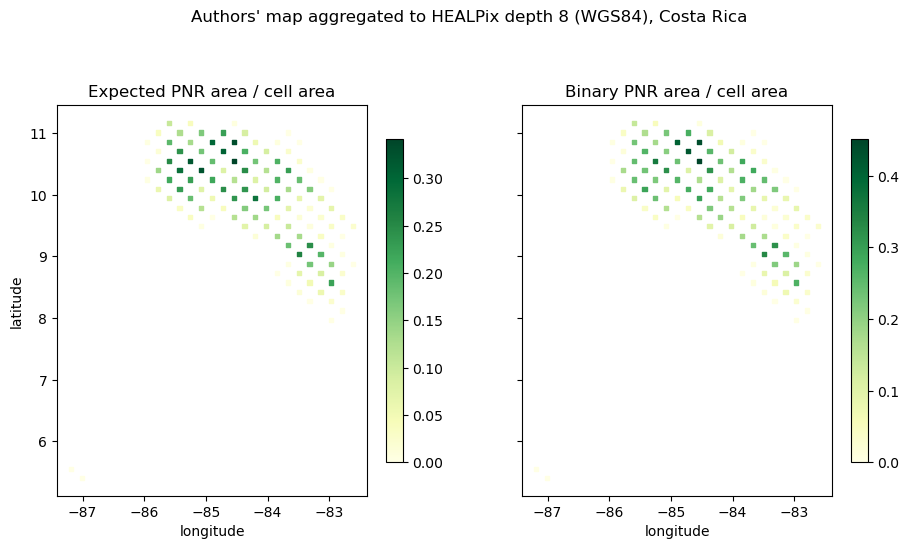

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 6), sharey=True)
frac = ds.expected_pnr / hp_cell_area
for ax, (v, title) in zip(axes, [(frac, "Expected PNR area / cell area"),
                                 (ds.area_bin_pnr / hp_cell_area, "Binary PNR area / cell area")]):
    sc = ax.scatter(ds.longitude, ds.latitude, c=v, s=9, marker="s", cmap="YlGn", vmin=0)
    ax.set_title(title)
    ax.set_xlabel("longitude")
    ax.set_aspect("equal")
    fig.colorbar(sc, ax=ax, shrink=0.7)
axes[0].set_ylabel("latitude")
fig.suptitle(f"Authors' map aggregated to HEALPix depth {HEALPIX_DEPTH} (WGS84), {COUNTRY}")
fig.savefig(FIGURES_DIR / ("step1_authors_map_healpix.png" if ISO3 == "COL" else f"step1_authors_map_healpix_{TAG}.png"), dpi=150, bbox_inches="tight")
plt.show()